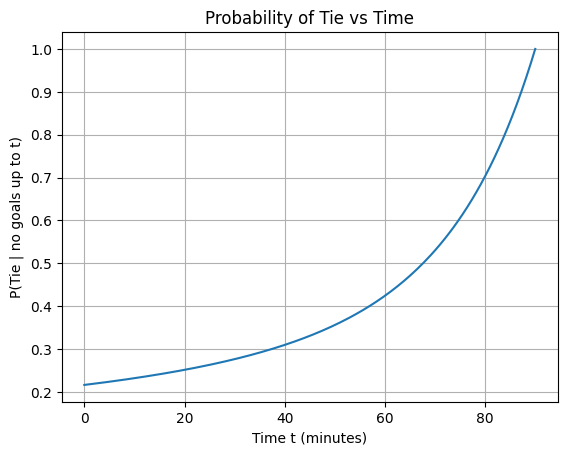

In [1]:
#problem 1 part b
import numpy as np
import matplotlib.pyplot as plt
from math import exp, factorial

#poisson pmf
def poisson_pmf(lam, k):
    return exp(-lam) * lam**k / factorial(k)

#compute p(x = y)
def prob_tie(lam1, lam2, max_k=20):
    return sum(poisson_pmf(lam1, k) * poisson_pmf(lam2, k) for k in range(max_k))

#rates per minute
lambda_A = 2 / 90
lambda_B = 1.5 / 90

#time grid
t_values = np.linspace(0, 90, 200)
probabilities = []

for t in t_values:
    T = 90 - t  #remaining time
    
    lamA = lambda_A * T
    lamB = lambda_B * T
    
    p = prob_tie(lamA, lamB)
    probabilities.append(p)

#plot
plt.plot(t_values, probabilities)
plt.xlabel("Time t (minutes)")
plt.ylabel("P(Tie | no goals up to t)")
plt.title("Probability of Tie vs Time")
plt.grid()
plt.savefig("hw7-pbm1b.png", dpi=300, bbox_inches="tight")
plt.show()

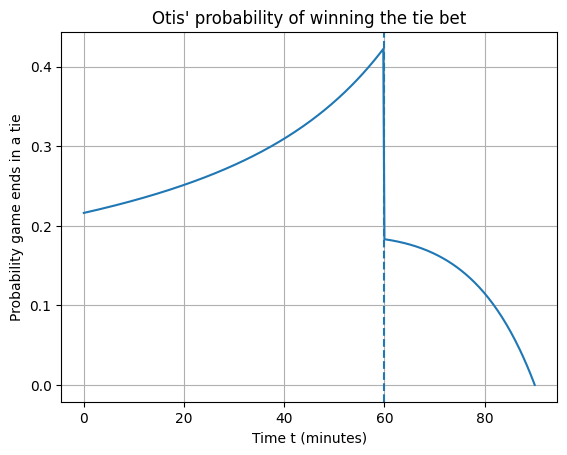

In [2]:
#problem 1c

#p(x = y)
def prob_same(lamA, lamB, max_k=30):
    return sum(poisson_pmf(lamA, k) * poisson_pmf(lamB, k) for k in range(max_k))

#p(y = x + 1)
def prob_B_one_more(lamA, lamB, max_k=30):
    return sum(poisson_pmf(lamA, k) * poisson_pmf(lamB, k+1) for k in range(max_k))

#rates per minute
rateA = 2 / 90
rateB = 1.5 / 90

#time values
t_vals = np.linspace(0, 90, 400)
p_vals = []

for t in t_vals:
    remaining = 90 - t
    lamA = rateA * remaining
    lamB = rateB * remaining
    
    if t < 60:
        #score is 0-0
        p = prob_same(lamA, lamB)
    else:
        #score is 1-0 to a
        p = prob_B_one_more(lamA, lamB)
    
    p_vals.append(p)

#plot
plt.plot(t_vals, p_vals)
plt.axvline(60, linestyle='--')
plt.xlabel("Time t (minutes)")
plt.ylabel("Probability game ends in a tie")
plt.title("Otis' probability of winning the tie bet")
plt.grid(True)
plt.savefig("hw7-pbm1c.png", dpi=300, bbox_inches="tight")
plt.show()